### Khan Academy Data Analysis

The objective of this project is to build a scalable and automated data pipeline for Khan Academy to monitor student performance on reading fluency tests. By synthesizing student registration data, attempt logs, and performance metrics with school-level administrative records, I aim to provide actionable insights through consolidated and school-specific trackers.

In [13]:
import os
data_path = os.path.join('.', 'data')

In [19]:
#importing tables
student_details = pd.read_json('data/StudentDetails.json')
student_details.head()


,id,name,contact_number,email_id,school_id,grade
0,CH_30943,Aja,911100221929,s2m_test_20942@tests2m.com,SCH_134123,Grade 1
1,CH_30309,Amare,911100221298,s2m_test_20298@tests2m.com,SCH_134028,Grade 4
2,CH_30168,Ameya,911100221162,s2m_test_20163@tests2m.com,SCH_134023,Grade 3
3,CH_30408,Ananda,911100221396,s2m_test_20399@tests2m.com,SCH_134057,Grade 2
4,CH_31164,Anantha,911100222154,s2m_test_21165@tests2m.com,SCH_134162,Grade 3


In [21]:
student_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1683 entries, 0 to 1682
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              1683 non-null   object
 1   name            1683 non-null   object
 2   contact_number  1683 non-null   int64 
 3   email_id        1683 non-null   object
 4   school_id       1683 non-null   object
 5   grade           1683 non-null   object
dtypes: int64(1), object(5)
memory usage: 79.0+ KB


In [23]:
cmf_input = pd.read_json('data/CMFInput.json')
cmf_input.head()

,id,child_id,school_id,submitted_at,status
0,CMF_IN0752,CH_31092,SCH_134141,2022-04-30 13:14:00,Processed
1,CMF_IN1271,CH_31051,SCH_134141,2022-04-30 11:45:27,Processed
2,CMF_IN0146,CH_31333,SCH_134211,2022-05-23 14:06:28,Processed
3,CMF_IN1386,CH_30251,SCH_134026,2022-04-30 12:15:47,Processed
4,CMF_IN1472,CH_30089,SCH_134018,2022-04-30 12:29:37,Processed


In [25]:
cmf_input.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1382 entries, 0 to 1381
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            1382 non-null   object        
 1   child_id      1382 non-null   object        
 2   school_id     1382 non-null   object        
 3   submitted_at  1382 non-null   datetime64[ns]
 4   status        1382 non-null   object        
dtypes: datetime64[ns](1), object(4)
memory usage: 54.1+ KB


In [27]:
cmf_metrics = pd.read_json('data/CMFMetrics.json')
cmf_metrics.head()

,id,input_id,processed_date,wpm,wcpm,pronunciation,fluency,noise
0,CMF_MT0897,CMF_IN0752,2022-04-30,173.0,170.1,1.00,0.95,41
1,CMF_MT0898,CMF_IN1271,2022-04-30,97.2,78.0,0.79,0.77,45
2,CMF_MT0899,CMF_IN0146,2022-05-23,139.3,129.7,0.91,0.88,15
3,CMF_MT0900,CMF_IN1386,2022-04-30,79.1,20.6,0.36,0.77,15
4,CMF_MT0901,CMF_IN1472,2022-04-30,152.4,150.7,0.97,0.90,15


In [29]:
cmf_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              1144 non-null   object 
 1   input_id        1144 non-null   object 
 2   processed_date  1144 non-null   object 
 3   wpm             1144 non-null   float64
 4   wcpm            1144 non-null   float64
 5   pronunciation   1144 non-null   float64
 6   fluency         1144 non-null   float64
 7   noise           1144 non-null   int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 71.6+ KB


In [31]:
form_response = pd.read_excel('data/Senior Data Analyst Assignment.xlsx', sheet_name='FormResponse')
form_response.head()


,form_submission_date,school_id,school_name,city,state,contact_number,email_id,no_of_students
0,2021-03-30 11:09:57,SCH_134213,School Name 134213,Delhi,Delhi,911100222445,test_21459@test.com,1200
1,2021-03-30 11:48:31,SCH_134040,School Name 134040,Amravati,Maharashtra,911100222446,test_21460@test.com,150
2,2021-03-31 03:59:03,SCH_134085,School Name 134085,Greater Noida,Uttar Pradesh,911100222447,test_21461@test.com,162
3,2021-03-31 04:22:44,SCH_134047,School Name 134047,Ghaziabad,Uttar Pradesh,911100222448,test_21462@test.com,150
4,2021-03-31 05:19:28,SCH_134018,School Name 134018,Pune,Maharashtra,911100222449,test_21463@test.com,750


In [33]:
form_response.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   form_submission_date  37 non-null     datetime64[ns]
 1   school_id             37 non-null     object        
 2   school_name           37 non-null     object        
 3   city                  37 non-null     object        
 4   state                 37 non-null     object        
 5   contact_number        37 non-null     int64         
 6   email_id              37 non-null     object        
 7   no_of_students        37 non-null     int64         
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 2.4+ KB


In [35]:
import sqlite3

In [37]:
conn = sqlite3.connect(':memory:')

#Load DataFrames into SQL tables
student_details.to_sql('student_details', conn, index=False)
cmf_input.to_sql('cmf_input', conn, index=False)
cmf_metrics.to_sql('cmf_metrics', conn, index=False)
form_response.to_sql('form_response', conn, index=False)


37

With the foundational tables established, we perform a series of SQL joins and transformations to synthesize a consolidated school tracker. This process involves mapping student attempts to their respective schools and calculating key performance indicators (KPIs) as outlined in the project requirements.

In [39]:
#querying to get the tracker dataframe
query = '''
SELECT f.school_id, f.school_name, f.no_of_students AS Total_Students,
count(DISTINCT s.id) as Registered_Users, count(ci.child_id) AS cmf_submitted, count(cm.id) AS cmf_successful,
avg(cm.wpm) as avg_wpm, avg(cm.wcpm) as avg_wcpm, avg(cm.pronunciation) as avg_pronunciation,
avg(cm.fluency) as avg_fluency
FROM student_details s
JOIN form_response f ON s.school_id = f.school_id
LEFT JOIN cmf_input ci ON s.id = ci.child_id
LEFT JOIN cmf_metrics cm ON ci.id = cm.input_id
GROUP BY f.school_id
ORDER BY f.school_id;
'''
tracker = pd.read_sql(query, conn)
#print(tracker)


In [41]:
tracker.head()

,school_id,school_name,Total_Students,Registered_Users,cmf_submitted,cmf_successful,avg_wpm,avg_wcpm,avg_pronunciation,avg_fluency
0,SCH_134011,School Name 134011,480,44,55,47,102.012766,80.312766,0.708511,0.794468
1,SCH_134014,School Name 134014,400,39,42,33,115.924242,98.812121,0.784242,0.830909
2,SCH_134016,School Name 134016,50,5,3,2,95.600000,69.100000,0.680000,0.610000
3,SCH_134018,School Name 134018,750,72,67,56,106.108929,86.650000,0.767321,0.807143
4,SCH_134023,School Name 134023,300,30,32,28,112.907143,96.092857,0.784643,0.823929


In [43]:
#export the new pandas df to a database
tracker.to_sql('tracker', conn, index=False)


37

In [47]:
query = '''
SELECT *
FROM tracker
WHERE school_id in ('SCH_134065','SCH_134141');
'''
school_specific = pd.read_sql(query, conn)
print(school_specific)

    school_id         school_name  Total_Students  Registered_Users  \
0  SCH_134065  School Name 134065            1200               115   
1  SCH_134141  School Name 134141            1500               126   

   cmf_submitted  cmf_successful     avg_wpm   avg_wcpm  avg_pronunciation  \
0            129              95  106.354737  87.591579           0.769579   
1            239             197   89.997462  65.615736           0.641066   

   avg_fluency  
0     0.786105  
1     0.763096  


A critical component of this project is providing schools with localized data to drive instructional decisions. Here, we generate detailed reports for specific school IDs (SCH_134065 and SCH_134141), offering a deep dive into student-level fluency metrics within those institutions.

In [49]:
school_specific

,school_id,school_name,Total_Students,Registered_Users,cmf_submitted,cmf_successful,avg_wpm,avg_wcpm,avg_pronunciation,avg_fluency
0,SCH_134065,School Name 134065,1200,115,129,95,106.354737,87.591579,0.769579,0.786105
1,SCH_134141,School Name 134141,1500,126,239,197,89.997462,65.615736,0.641066,0.763096


In [51]:
#querying to get the tracker dataframe
query2 = '''
SELECT s.grade as grade,
count(s.id) as Registered_Users, count(ci.child_id) AS cmf_submitted, count(cm.id) AS cmf_successful,
avg(cm.wpm) as avg_wpm, avg(cm.wcpm) as avg_wcpm, avg(cm.pronunciation) as avg_pronunciation,
avg(cm.fluency) as avg_fluency
FROM student_details s
JOIN form_response f ON s.school_id = f.school_id
LEFT JOIN cmf_input ci ON s.id = ci.child_id
LEFT JOIN cmf_metrics cm ON ci.id = cm.input_id
GROUP BY grade
ORDER BY grade;
'''
grade_wise = pd.read_sql(query2, conn)

In [53]:
grade_wise

,grade,Registered_Users,cmf_submitted,cmf_successful,avg_wpm,avg_wcpm,avg_pronunciation,avg_fluency
0,Grade 1,492,430,361,66.890305,39.505817,0.502798,0.656565
1,Grade 2,482,432,366,90.175956,64.800546,0.651639,0.766639
2,Grade 3,477,428,354,90.543785,64.022881,0.643672,0.773927
3,Grade 4,733,661,545,132.895046,121.627523,0.882514,0.865303


In [55]:
grade_wise['Registered_Users'].sum()

2184

**Additional Analysis of the tracker data.**


1.   Fluency benchmarking my state

Let's analyse the fluency scores of students based on different geographical locations to see relative performance of the students from different locations.

In [162]:
query3 = '''
SELECT f.state as state,
count(s.id) as Registered_Users, count(ci.child_id) AS cmf_submitted, count(cm.id) AS cmf_successful,
avg(cm.wpm) as avg_wpm, avg(cm.wcpm) as avg_wcpm, avg(cm.pronunciation) as avg_pronunciation,
avg(cm.fluency) as avg_fluency
FROM student_details s
JOIN form_response f ON s.school_id = f.school_id
LEFT JOIN cmf_input ci ON s.id = ci.child_id
LEFT JOIN cmf_metrics cm ON ci.id = cm.input_id
GROUP BY state
ORDER BY avg_fluency DESC;
'''
state_wise = pd.read_sql(query3, conn)
state_wise


,state,Registered_Users,cmf_submitted,cmf_successful,avg_wpm,avg_wcpm,avg_pronunciation,avg_fluency
0,Jammu and Kashmir,34,32,28,112.907143,96.092857,0.784643,0.823929
1,Uttar Pradesh,112,103,88,102.639773,80.144318,0.704659,0.791932
2,Rajasthan,69,56,44,97.915909,76.684091,0.703636,0.787273
3,Telangana,145,129,95,106.354737,87.591579,0.769579,0.786105
4,Tamil Nadu,180,161,132,103.306818,83.171970,0.723485,0.783485
5,Delhi,156,138,117,101.055556,80.393162,0.708205,0.778462
6,Maharashtra,1199,1083,923,97.850488,76.119935,0.683662,0.775720
7,Karnataka,284,246,197,96.747208,74.667513,0.660152,0.758274
8,Uttarakhand,5,3,2,95.600000,69.100000,0.680000,0.610000


In [164]:
cols_to_norm = ['avg_wpm','avg_wcpm']
state_wise[cols_to_norm] = state_wise[cols_to_norm].apply(lambda x: (x - x.min()) / (x.max() - x.min()))
state_wise

,state,Registered_Users,cmf_submitted,cmf_successful,avg_wpm,avg_wcpm,avg_pronunciation,avg_fluency
0,Jammu and Kashmir,34,32,28,1.000000,1.000000,0.784643,0.823929
1,Uttar Pradesh,112,103,88,0.406755,0.409157,0.704659,0.791932
2,Rajasthan,69,56,44,0.133812,0.280967,0.703636,0.787273
3,Telangana,145,129,95,0.621405,0.685055,0.769579,0.786105
4,Tamil Nadu,180,161,132,0.445297,0.521322,0.723485,0.783485
5,Delhi,156,138,117,0.315220,0.418376,0.708205,0.778462
6,Maharashtra,1199,1083,923,0.130032,0.260066,0.683662,0.775720
7,Karnataka,284,246,197,0.066285,0.206259,0.660152,0.758274
8,Uttarakhand,5,3,2,0.000000,0.000000,0.680000,0.610000


let's compare two numerically similar parameters : 

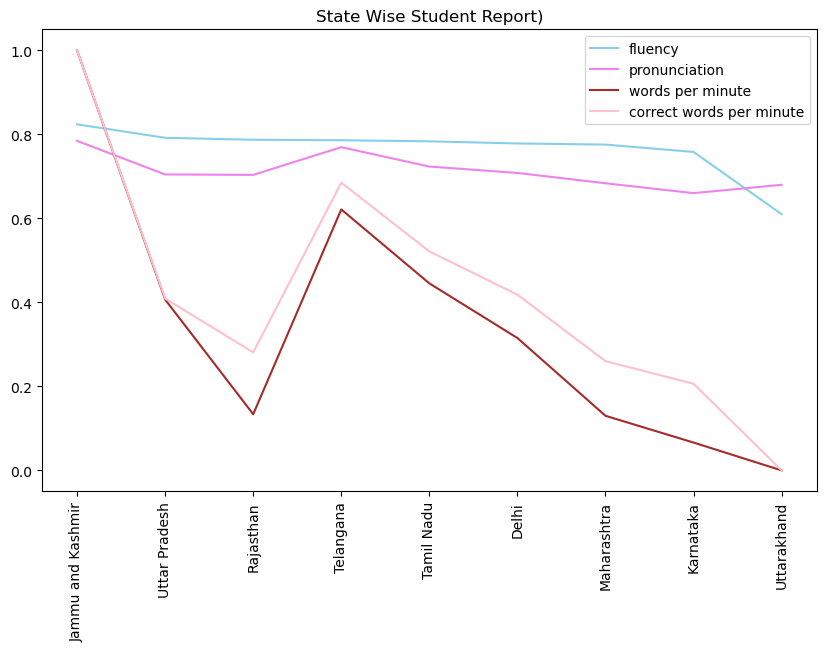

In [166]:
plt.figure(figsize=(10, 6))

plt.plot(state_wise['state'], state_wise['avg_fluency'], label='fluency', color = 'skyblue')
plt.plot(state_wise['state'], state_wise['avg_pronunciation'],label='pronunciation', color = 'violet')
plt.plot(state_wise['state'], state_wise['avg_wpm'], label='words per minute', color = 'brown')
plt.plot(state_wise['state'], state_wise['avg_wcpm'], label='correct words per minute', color = 'pink')


plt.title('State Wise Student Report)')
plt.xticks(rotation=90)
plt.legend()
plt.show()

The least performing state is Uttarakhand where more literary reources might be required in the future. Moreover, efforts should be made to increase the number of app users in the state.

2. Participation Gap Analysis

This query identifies which schools have low participation despite high registrations. With the help of this analysis, the Khan Academy team can reach out these schools and work towards increasing student participation in tests.

In [110]:
query4 = '''
SELECT f.school_id, f.school_name, f.no_of_students AS Target_Enrollment,
count(DISTINCT s.id) as Registered_Users, COUNT(DISTINCT ci.child_id) AS Actual_Participants ,
round(100.0 * count(distinct ci.child_id)/ f.no_of_students, 2) AS Participation_Rate
FROM student_details s
JOIN form_response f ON s.school_id = f.school_id
LEFT JOIN cmf_input ci ON s.id = ci.child_id
LEFT JOIN cmf_metrics cm ON ci.id = cm.input_id
GROUP BY f.school_id
ORDER BY f.school_id;

'''

participation_gap = pd.read_sql(query4, conn)
participation_gap

,school_id,school_name,Target_Enrollment,Registered_Users,Actual_Participants,Participation_Rate
0,SCH_134011,School Name 134011,480,44,38,7.92
1,SCH_134014,School Name 134014,400,39,31,7.75
2,SCH_134016,School Name 134016,50,5,3,6.00
3,SCH_134018,School Name 134018,750,72,57,7.60
4,SCH_134023,School Name 134023,300,30,28,9.33
5,SCH_134026,School Name 134026,1000,95,78,7.80
6,SCH_134028,School Name 134028,500,47,44,8.80
7,SCH_134031,School Name 134031,200,20,19,9.50
8,SCH_134040,School Name 134040,150,15,12,8.00
9,SCH_134047,School Name 134047,150,15,14,9.33


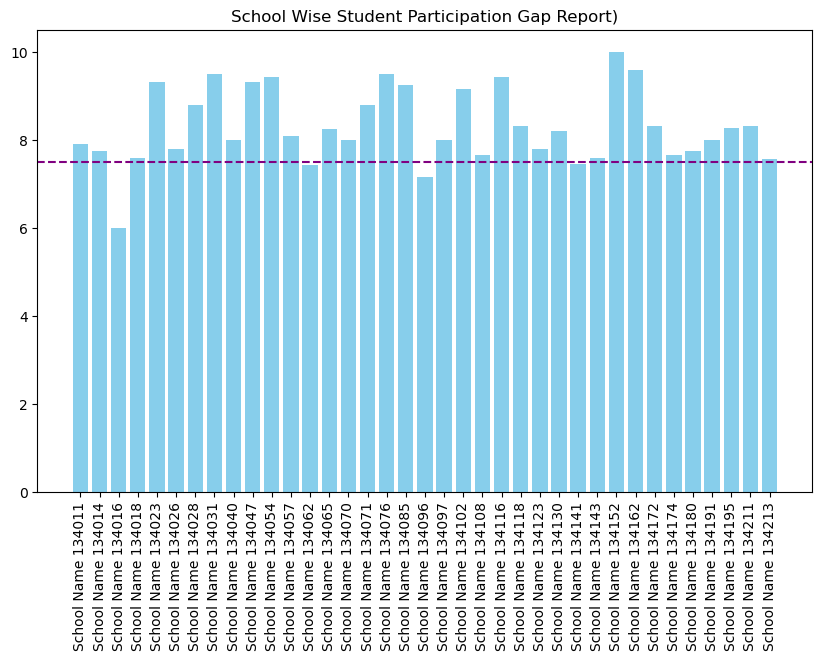

In [130]:
plt.figure(figsize=(10, 6))
plt.bar(participation_gap['school_name'], participation_gap['Participation_Rate'], color='skyblue')
plt.title('School Wise Student Participation Gap Report)')
plt.xticks(rotation=90)
threshold = 7.5
plt.axhline(y=threshold, color='purple', linestyle='--', label=f'Threshold ({threshold})')

plt.show()